# **🍽️ Food Recommendation & Semantic Search Chatbot**
This project presents an AI-powered food recommendation and semantic search chatbot that understands both Arabic and English food queries using modern Natural Language Processing (NLP) techniques.

The system is based on Text Embedding technology using the multilingual transformer model:

paraphrase-multilingual-mpnet-base-v2

-----------------------------------------------------------------------------------

# 📌 What are Text Embeddings?

Text embeddings are dense numerical vector representations of text generated by transformer-based deep learning models.

Instead of comparing words using exact string matching, embeddings allow the system to understand:

semantic meaning
context
similarity between sentences and food names

----------------------------------------------------------------------------------------

# The project uses a transformer-based embedding model derived from MPNet/BERT architectures.

The workflow is:

User Query

        ↓

Text Embedding Model

         ↓

Vector Representation

         ↓

Cosine Similarity

         ↓

Most Similar Food Results

The model converts both the dataset and user queries into embeddings, then retrieves the most semantically similar food items.
-------------------------------------------------------------------------------------------

# 🌍 Multilingual Support

The chatbot supports both:

English food queries
Arabic food queries

Arabic queries are translated and normalized before semantic retrieval.

Examples:

بيتزا  → pizza

كشري  → koshary

شاورما → shawarma

-------------------------------------------------------------------------------------------

# The model performance is evaluated using retrieval-based metrics such as:

Top-1 Accuracy

Top-3 Accuracy

Similarity Score

In [ ]:
!touch train.py
!pip install torch torchvision transformers scikit-learn pillow
!python train.py --data_dir path/to/dataset --mode feature_extraction

# Install

In [ ]:
# Step 1: Install
!pip install sentence-transformers pandas numpy scikit-learn

# Step 2
!python text_model.py

python3: can't open file '/content/text_model.py': [Errno 2] No such file or directory


In [ ]:
!pip install deep_translator

# Data

In [ ]:
import pandas as pd
df = pd.read_csv('final_matched_dataset (1).csv')
print(df.shape)
print(df.columns.tolist())
print(df.head(3))

(13829, 9)
['name', 'matched_name', 'ingredients', 'category', 'portion', 'calories', 'protein', 'fat', 'carb']
             name matched_name  \
0   chicken handi      chicken   
1   chicken mandi      chicken   
2  sticky chicken      chicken   

                                         ingredients category portion  \
0  Chicken, Onion, Tomatoes, Garlic, Ginger paste...     meat   100 g   
1  Chicken, Basmati Rice, Water, Onion, Garlic, G...     meat   100 g   
2  Chicken drumsticks, Soy Sauce, Honey, Olive Oi...     meat   100 g   

   calories  protein   fat  carb  
0     166.0     21.4  1.79   0.0  
1     166.0     21.4  1.79   0.0  
2     166.0     21.4  1.79   0.0  


# Model

In [ ]:


import pickle, re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from deep_translator import GoogleTranslator


# ══════════════════════════════════════════════════════════════
# ⚙️  Config
# ══════════════════════════════════════════════════════════════
MODEL_NAME      = "paraphrase-multilingual-mpnet-base-v2"
EMBEDDINGS_PATH = "food_embeddings_v2.pkl"
CSV_PATH        = "final_matched_dataset (1).csv"

THRESHOLD_SINGLE = 0.78
THRESHOLD_DOUBLE = 0.60
THRESHOLD_MIN    = 0.32


# ══════════════════════════════════════════════════════════════
# 🌍  Arabic Support
# ══════════════════════════════════════════════════════════════
ARABIC_FOOD_MAP = {
    "بيتزا": "pizza",       "بيتزه": "pizza",
    "برجر": "burger",       "همبرجر": "burger",
    "شاورما": "shawarma",   "شاورمة": "shawarma",
    "فلافل": "falafel",
    "كشري": "koshari",      "كشرى": "koshari",    "كوشري": "koshari",
    "حمص": "hummus",
    "كباب": "kebab",
    "فراخ": "chicken",      "دجاج": "chicken",    "فرخة": "chicken",
    "سمك": "fish",          "سمكة": "fish",
    "رز": "rice",           "أرز": "rice",
    "معكرونة": "pasta",     "مكرونة": "pasta",
    "بطاطس": "potato",      "بطاطا": "potato",
    "سلطة": "salad",
    "شوربة": "soup",        "حساء": "soup",
    "بيض": "eggs",          "بيضة": "egg",
    "خبز": "bread",         "عيش": "bread",
    "جبنة": "cheese",       "جبن": "cheese",
    "لبن": "yogurt",        "زبادي": "yogurt",
    "عصير": "juice",
    "قهوة": "coffee",
    "شاي": "tea",
    "آيس كريم": "ice cream","ايس كريم": "ice cream",
    "شوكولاتة": "chocolate","شيكولاتة": "chocolate",
    "كيك": "cake",
    "موز": "banana",
    "تفاحة": "apple",       "تفاح": "apple",
    "برتقال": "orange",     "برتقالة": "orange",
    "مانجو": "mango",
    "فراولة": "strawberry",
    "بطيخ": "watermelon",
    "عنب": "grape",
    "سوشي": "sushi",
    "ستيك": "steak",        "لحم": "beef",
    "سندويش": "sandwich",   "ساندويتش": "sandwich",
    "وافل": "waffle",
    "بان كيك": "pancake",   "فطيرة": "pancake",
    "دونات": "donut",
    "بسكويت": "cookie",
    "سموزي": "smoothie",
    "شوفان": "oatmeal",
    "أفوكادو": "avocado",
    "فطر": "mushroom",
    "ذرة": "corn",
    "طماطم": "tomato",      "بندورة": "tomato",
    "بصل": "onion",
    "ثوم": "garlic",
    "سبانخ": "spinach",
    "بروكلي": "broccoli",
}

def is_arabic(text: str) -> bool:
    return bool(re.search(r'[\u0600-\u06FF]', text))

def translate_to_english(text: str) -> str:
    text_clean = text.strip().lower()
    for ar, en in ARABIC_FOOD_MAP.items():
        if ar in text_clean:
            return text_clean.replace(ar, en)
    try:
        return GoogleTranslator(source="ar", target="en").translate(text)
    except Exception:
        return text


# ══════════════════════════════════════════════════════════════
#   Query Expansion
# ══════════════════════════════════════════════════════════════
QUERY_EXPANSIONS = {
    "pizza":      ["pizza pie", "italian pizza", "pizza slice"],
    "burger":     ["hamburger", "beef burger", "cheeseburger"],
    "chicken":    ["poultry", "grilled chicken", "chicken breast"],
    "salad":      ["green salad", "vegetable salad"],
    "fries":      ["french fries", "fried potatoes"],
    "egg":        ["eggs", "omelette", "scrambled eggs"],
    "rice":       ["steamed rice", "white rice"],
    "pasta":      ["spaghetti", "noodles", "macaroni"],
    "sushi":      ["japanese rice roll", "maki"],
    "ice cream":  ["gelato", "frozen dessert"],
    "koshary": [
    "koshari",
    "egyptian koshary",
    "egyptian lentil rice",
    "rice lentils pasta"],
    # "koshari":    ["koshary", "egyptian lentil rice"],
    "falafel":    ["fried chickpea", "egyptian falafel"],
    "shawarma":   ["shawarma wrap", "meat wrap"],
    "hummus":     ["chickpea dip", "tahini hummus"],
    "kebab":      ["grilled kebab", "lamb kebab"],
    "coffee":     ["espresso", "brewed coffee"],
    "banana":     ["ripe banana", "banana fruit"],
    "sandwich":   ["sub sandwich", "wrap"],
    "soup":       ["broth", "stew"],
    "cake":       ["sponge cake", "layered cake"],
    "chocolate":  ["dark chocolate", "cocoa"],
    "fish":       ["seafood", "grilled fish"],
    "steak":      ["beef steak", "grilled steak"],
    "bread":      ["loaf bread", "toast"],
    "pancake":    ["pancakes", "flapjack"],
    "waffle":     ["waffles", "belgian waffle"],
    "donut":      ["doughnut", "glazed donut"],
    "cookie":     ["biscuit", "chocolate chip cookie"],
    "yogurt":     ["greek yogurt", "curd"],
    "cheese":     ["cheddar", "mozzarella"],
    "smoothie":   ["fruit smoothie", "blended drink"],
    "oatmeal":    ["oats", "porridge"],
    "avocado":    ["avocado toast", "guacamole"],
    "mushroom":   ["mushrooms", "sauteed mushroom"],
    "potato":     ["mashed potato", "baked potato"],
    "tomato":     ["fresh tomato", "tomato sauce"],
    "spinach":    ["baby spinach"],
    "broccoli":   ["steamed broccoli"],
}

def expand_query(query: str) -> list:
    q = query.strip().lower()
    expansions = [q]
    for key, vals in QUERY_EXPANSIONS.items():
        if key == q or key in q.split():
            expansions.extend(vals)
            break
    return list(dict.fromkeys(expansions))


# ══════════════════════════════════════════════════════════════
#   Data — Load / Build / Save
# ══════════════════════════════════════════════════════════════
def load_and_clean_csv(csv_path: str = CSV_PATH) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["name"] = df["name"].str.strip().str.lower()
    df = df.dropna(subset=["calories"])
    df = df[df["calories"] > 0]
    for col in ["protein", "fat", "carb"]:
        df[col] = df[col].fillna(0)
    df["text_for_embedding"] = (
        df["name"].fillna("") + " " +
        df["name"].fillna("") + " " +
        df["ingredients"].fillna("") + " " +
        df["category"].fillna("")
    )
    df = df.groupby("name", as_index=False).agg({
        "text_for_embedding": "first",
        "ingredients":        "first",
        "category":           "first",
        "portion":            "first",
        "calories":           "mean",
        "protein":            "mean",
        "fat":                "mean",
        "carb":               "mean",
    })
    for col in ["calories", "protein", "fat", "carb"]:
        df[col] = df[col].round(1)
    print(f"[CSV] {len(df):,} صنف بعد التنظيف")
    return df.reset_index(drop=True)

def build_and_save_embeddings(df: pd.DataFrame, model: SentenceTransformer) -> np.ndarray:
    print(f"[Embedding] بيعمل embed لـ {len(df):,} صنف ...")
    emb = model.encode(
        df["text_for_embedding"].tolist(),
        batch_size=256,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    with open(EMBEDDINGS_PATH, "wb") as f:
        pickle.dump({"embeddings": emb, "df": df}, f)
    print(f"[Embedding] {EMBEDDINGS_PATH}")
    return emb

def load_embeddings() -> tuple:
    with open(EMBEDDINGS_PATH, "rb") as f:
        data = pickle.load(f)
    print(f"[Embedding] {EMBEDDINGS_PATH}")
    return data["embeddings"], data["df"]

def load_model() -> SentenceTransformer:
    print(f"[Model]{MODEL_NAME} ...")
    return SentenceTransformer(MODEL_NAME)

def initialize(csv_path: str = CSV_PATH) -> tuple:
    model = load_model()
    if Path(EMBEDDINGS_PATH).exists():
        embeddings, df = load_embeddings()
    else:
        df         = load_and_clean_csv(csv_path)
        embeddings = build_and_save_embeddings(df, model)
    return model, embeddings, df


# ══════════════════════════════════════════════════════════════
# 🔎  Search
# ══════════════════════════════════════════════════════════════
DIET_KEYWORDS = {
    "فيجيتاريان": ["vegetarian", "veggie", "plant"],
    "فيجان":       ["vegan"],
    "بدون جلوتين": ["gluten-free", "gluten free"],
    "صيام":        ["light", "low calorie", "salad", "soup"],
}

def search_food(
    query:       str,
    model:       SentenceTransformer,
    embeddings:  np.ndarray,
    df:          pd.DataFrame,
    top_k:       int   = 3,
    max_cal:     float = None,
    min_cal:     float = None,
    diet_filter: str   = None,
) -> list:
    original = query
    if is_arabic(query):
        query = translate_to_english(query)

    queries   = expand_query(query.strip().lower())
    print("Expanded Queries:", queries)
    vecs      = model.encode(queries, normalize_embeddings=True)
    query_vec = vecs.mean(axis=0, keepdims=True)
    query_vec /= np.linalg.norm(query_vec) + 1e-9

    scores = cosine_similarity(query_vec, embeddings)[0].copy()

    query_words = set(query.strip().lower().split())
    for i, cat in enumerate(df["category"].fillna("").str.lower()):
        if query_words & set(cat.replace("-", " ").split()):
            scores[i] = min(1.0, scores[i] * 1.08)

    for i, name in enumerate(df["name"].fillna("").str.lower()):

        q = query.strip().lower()

        # Exact match
        if q == name:
            scores[i] *= 1.50

        # Starts with query
        elif name.startswith(q):
            scores[i] *= 1.35

        # Partial match
        elif q in name:
            scores[i] *= 1.20

        # Word overlap
        elif any(w in name for w in query_words if len(w) > 3):
            scores[i] *= 1.10

    mask = np.ones(len(df), dtype=bool)
    if max_cal is not None:
        mask &= df["calories"].values <= max_cal
    if min_cal is not None:
        mask &= df["calories"].values >= min_cal
    if diet_filter and diet_filter != "الكل":
        kws = DIET_KEYWORDS.get(diet_filter, [])
        if kws:
            diet_mask = (
                df["ingredients"].fillna("").str.lower()
                  .apply(lambda x: any(k in x for k in kws))
                | df["name"].fillna("").str.lower()
                  .apply(lambda x: any(k in x for k in kws))
            )
            mask &= diet_mask.values
    scores[~mask] = -1

    top_idx = np.argsort(scores)[::-1][:top_k]
    results = []
    for idx in top_idx:
        if scores[idx] < 0:
            continue
        row = df.iloc[idx]
        results.append({
            "name":        row["name"],
            "category":    row["category"],
            "portion":     row["portion"],
            "calories":    row["calories"],
            "protein":     row["protein"],
            "fat":         row["fat"],
            "carb":        row["carb"],
            "ingredients": row["ingredients"],
            "score":       round(float(scores[idx]), 3),
            "translated":  query if is_arabic(original) else None,
        })
    return results

def smart_count(results: list) -> list:
    if not results:
        return []
    s = results[0]["score"]
    if s >= THRESHOLD_SINGLE: return results[:1]
    if s >= THRESHOLD_DOUBLE: return results[:2]
    if s >= THRESHOLD_MIN:    return results[:3]
    return []

def get_similar(result: dict, df: pd.DataFrame, n: int = 4) -> list:
    sim = df[
        (df["category"] == result["category"]) &
        (df["name"]     != result["name"]) &
        (df["calories"].between(result["calories"] - 60, result["calories"] + 60))
    ]
    return sim["name"].head(n).tolist()



try:
    MODEL, EMBEDDINGS, DF = initialize()
    MODEL_LOADED = True
    print(f"✅ اتحمّل! عندك {len(DF):,} صنف في الـ dataset")
except Exception as _e:
    MODEL_LOADED = False
    LOAD_ERROR   = str(_e)
    print(f"❌ مشكلة: {_e}")


# ══════════════════════════════════════════════════════════════
# 🎨  CSS
# ══════════════════════════════════════════════════════════════
CSS = """
<style>
.chat-wrap    { font-family:'Segoe UI',Arial,sans-serif; max-width:700px; }
.chat-box     { background:#f5f5f5; border-radius:12px; padding:16px;
                min-height:300px; max-height:500px; overflow-y:auto;
                display:flex; flex-direction:column; gap:10px; }
.msg-row-user { display:flex; justify-content:flex-end; }
.msg-row-bot  { display:flex; justify-content:flex-start; }
.bubble-user  { background:#5c35b5; color:#fff; padding:10px 16px;
                border-radius:18px 18px 4px 18px; max-width:70%;
                font-size:14px; line-height:1.5; }
.bubble-bot   { background:#fff; border:1px solid #e0e0e0; padding:10px 16px;
                border-radius:18px 18px 18px 4px; max-width:80%;
                font-size:14px; line-height:1.5; color:#222; }
.bubble-err   { background:#fff3e0; border:1px solid #ffcc02;
                border-radius:12px; padding:10px 16px; font-size:13px;
                color:#bf6f00; max-width:78%; }
.result-card  { background:#f9f9f9; border:1px solid #e0e0e0;
                border-radius:10px; padding:10px 14px; margin-top:8px; }
.result-name  { font-weight:700; font-size:15px; color:#1a1a1a;
                margin-bottom:5px; text-transform:capitalize; }
.macro-row    { display:flex; flex-wrap:wrap; gap:6px; margin:5px 0; }
.macro-chip   { background:#ede7f6; color:#4527a0; border-radius:20px;
                padding:2px 10px; font-size:12px; font-weight:500; }
.score-bar-bg { background:#e0e0e0; border-radius:4px; height:5px; margin-top:7px; }
.score-bar-fg { height:5px; border-radius:4px; }
.score-lbl    { font-size:11px; color:#888; margin-top:3px; }
.tr-note      { font-size:11px; color:#888; margin-bottom:6px; font-style:italic; }
.similar-wrap { margin-top:8px; font-size:12px; color:#555; }
.similar-chip { display:inline-block; background:#e8f5e9; color:#2e7d32;
                border-radius:20px; padding:2px 10px; margin:2px; font-size:12px; }
.time-lbl     { font-size:10px; color:#bbb; margin-top:4px; text-align:right; }
.thinking     { color:#999; font-style:italic; font-size:13px; }
</style>
"""


# ══════════════════════════════════════════════════════════════
# 🧱  HTML Builders
# ══════════════════════════════════════════════════════════════
def _score_color(s):
    if s >= 0.78: return "#2e7d32"
    if s >= 0.60: return "#f57f17"
    return "#e53935"

def _result_card(r):
    pct   = int(r["score"] * 100)
    color = _score_color(r["score"])

    tr_note = (f'<div class="tr-note"> "{r["translated"]}"</div>'
               if r.get("translated") else "")

    macros = "".join([
        f'<span class="macro-chip">🔥 {r["calories"]} cal</span>',
        f'<span class="macro-chip">🥩 {r["protein"]}g protein</span>',
        f'<span class="macro-chip">🧈 {r["fat"]}g fat</span>',
        f'<span class="macro-chip">🍞 {r["carb"]}g carb</span>',
    ])

    portion_cat = ""
    if r.get("portion") or r.get("category"):
        portion_cat = (f'<div style="font-size:12px;color:#888;margin-bottom:6px;">'
                       f'{r.get("portion","")} &nbsp;·&nbsp; {r.get("category","")}</div>')

    ingredients = ""
    if r.get("ingredients"):
        ing = str(r["ingredients"])[:120]
        if len(str(r["ingredients"])) > 120: ing += "..."
        ingredients = f'<div style="font-size:12px;color:#777;margin-top:5px;">🧂 {ing}</div>'

    similar_html = ""
    if MODEL_LOADED:
        sim = get_similar(r, DF, n=4)
        if sim:
            chips = "".join(f'<span class="similar-chip">{s.title()}</span>' for s in sim)
            similar_html = f'<div class="similar-wrap">مشابه: {chips}</div>'

    return f"""<div class="result-card">
      {tr_note}
      <div class="result-name">{r["name"].title()}</div>
      {portion_cat}
      <div class="macro-row">{macros}</div>
      {ingredients}
      <div class="score-bar-bg">
        <div class="score-bar-fg" style="width:{pct}%;background:{color}"></div>
      </div>
      <div class="score-lbl">Confidence: {pct}%</div>
      {similar_html}
    </div>"""

def _user_bubble(text):
    t = datetime.now().strftime("%H:%M")
    return f"""<div class="msg-row-user"><div>
      <div class="bubble-user">{text}</div>
      <div class="time-lbl">{t}</div>
    </div></div>"""

def _bot_bubble(inner):
    t = datetime.now().strftime("%H:%M")
    return f"""<div class="msg-row-bot"><div style="max-width:82%">
      <div class="bubble-bot">{inner}</div>
      <div class="time-lbl">{t}</div>
    </div></div>"""

def _err_bubble(msg):
    return f'<div class="msg-row-bot"><div class="bubble-err">⚠️ {msg}</div></div>'


# ══════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════
def run_chatbot():
    if not MODEL_LOADED:
        display(HTML(f'<p style="color:red">❌ فشل تحميل الـ model: <code>{LOAD_ERROR}</code></p>'))
        return

    WELCOME = _bot_bubble(
        "مرحباً! 👋<br>"
        "ابعتلي اسم أكل بالعربي أو الإنجليزي وأنا هجيب ليك معلوماته الغذائية.<br>"
        "<span style='font-size:12px;color:#888;'>"
        "مثال: <b>pizza</b> · <b>بيتزا</b> · <b>grilled chicken</b> · <b>كشري</b>"
        "</span>"
    )
    history = [WELCOME]

    # ── Widgets ──────────────────────────────────────────────
    chat_out  = widgets.Output()
    query_in  = widgets.Text(
        placeholder="اكتب اسم الأكل هنا... (عربي أو إنجليزي)",
        layout=widgets.Layout(width="72%", height="36px")
    )
    send_btn  = widgets.Button(
        description="إرسال ↗", button_style="primary",
        layout=widgets.Layout(width="105px", height="36px")
    )
    clear_btn = widgets.Button(
        description="مسح 🗑",
        layout=widgets.Layout(width="90px", height="36px")
    )
    max_cal   = widgets.BoundedIntText(
        value=0, min=0, max=5000, step=50, description="Max cal:",
        style={"description_width": "60px"},
        layout=widgets.Layout(width="165px")
    )
    diet_dd   = widgets.Dropdown(
        options=["الكل", "فيجيتاريان", "فيجان", "بدون جلوتين", "صيام"],
        value="الكل", description="Diet:",
        style={"description_width": "40px"},
        layout=widgets.Layout(width="185px")
    )

    # ── render ───────────────────────────────────────────────
    def render():
        with chat_out:
            clear_output(wait=True)
            display(HTML(
                CSS + '<div class="chat-wrap"><div class="chat-box">'
                + "".join(history) +
                "</div></div>"
            ))

    render()

    # ── callbacks ────────────────────────────────────────────
    def on_send(_=None):
        q = query_in.value.strip()
        if not q: return
        query_in.value = ""

        history.append(_user_bubble(q))
        history.append('<div class="msg-row-bot"><div class="bubble-bot thinking">⏳ جاري البحث...</div></div>')
        render()

        mc = max_cal.value if max_cal.value > 0 else None
        dt = diet_dd.value if diet_dd.value != "الكل" else None

        try:
            raw     = search_food(q, MODEL, EMBEDDINGS, DF, top_k=3, max_cal=mc, diet_filter=dt)
            results = smart_count(raw)
        except Exception as e:
            history.pop()
            history.append(_err_bubble(f"حصل error: {e}"))
            render()
            return

        history.pop()  # thinking

        if not results:
            history.append(_bot_bubble(
                f'مش لاقي نتيجة لـ "<b>{q}</b>".<br>'
                '<span style="font-size:12px;color:#888;">جرب كلمة تانية أو تأكد من الإملاء.</span>'
            ))
        else:
            cards = "".join(_result_card(r) for r in results)
            history.append(_bot_bubble(
                f'وجدت <b>{len(results)}</b> نتيجة لـ "<b>{q}</b>":{cards}'
            ))

        render()

    def on_clear(_):
        history.clear()
        history.append(WELCOME)
        render()

    send_btn.on_click(on_send)
    clear_btn.on_click(on_clear)
    query_in.on_submit(on_send)

    # ── layout ───────────────────────────────────────────────
    display(widgets.VBox([
        widgets.HTML('<h3 style="font-family:sans-serif;margin:10px 0 4px;">🍽️ Food Search Chatbot</h3>'),
        widgets.HBox([max_cal, diet_dd,
                      widgets.HTML('<span style="font-size:12px;color:#888;align-self:center;">فلاتر اختيارية</span>')],
                     layout=widgets.Layout(gap="12px", margin="0 0 6px 0")),
        chat_out,
        widgets.HBox([query_in, send_btn, clear_btn],
                     layout=widgets.Layout(gap="8px", margin="8px 0 0 0")),
    ]))



if __name__ == "__main__":
    run_chatbot()

⏳ بيحمّل الـ model... استنّي شوية
[Model] بيحمّل paraphrase-multilingual-mpnet-base-v2 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Embedding] اتحمّل من food_embeddings_v2.pkl
✅ اتحمّل! عندك 13,462 صنف في الـ dataset


# Evaluation / Accuracy Test

In [ ]:

test_cases = [

    # English
    ("pizza", "pizza"),
    ("burger", "burger"),
    ("shawarma", "shawarma"),
    ("falafel", "falafel"),
    ("sushi", "sushi"),
    ("ice cream", "ice cream"),

    # Arabic
    ("بيتزا", "pizza"),
    ("برجر", "burger"),
    ("شاورما", "shawarma"),
    ("كشري", "koshari"),
    ("فلافل", "falafel"),
    ("آيس كريم", "ice cream"),
]

top1_correct = 0
top3_correct = 0

all_scores = []

for query, expected in test_cases:

    results = search_food(
        query=query,
        model=MODEL,
        embeddings=EMBEDDINGS,
        df=DF,
        top_k=3
    )

    names = [r["name"].lower() for r in results]

    print(f"\n🔍 Query: {query}")
    print(f"Expected: {expected}")
    print("Results:", names)

    # ── Top 1 Accuracy ─────────────────────
    if len(names) > 0:
        if expected in names[0]:
            top1_correct += 1

    # ── Top 3 Accuracy ─────────────────────
    if any(expected in n for n in names):
        top3_correct += 1

    # ── similarity score ───────────────────
    if len(results) > 0:
        all_scores.append(results[0]["score"])


# ══════════════════════════════════════════════════════════════
# 📊 Final Metrics
# ══════════════════════════════════════════════════════════════

n = len(test_cases)

top1_accuracy = top1_correct / n
top3_accuracy = top3_correct / n

avg_score = np.mean(all_scores)

print("\n" + "="*50)
print("📊 EVALUATION RESULTS")
print("="*50)

print(f"✅ Top-1 Accuracy : {top1_accuracy:.2%}")
print(f"✅ Top-3 Accuracy : {top3_accuracy:.2%}")
print(f"✅ Average Similarity Score : {avg_score:.3f}")

print("="*50)

Expanded Queries: ['pizza', 'pizza pie', 'italian pizza', 'pizza slice']

🔍 Query: pizza
Expected: pizza
Results: ['pizza express margherita', 'pizza bianca with scamorza and shaved celery root', 'pizza dough']
Expanded Queries: ['burger', 'hamburger', 'beef burger', 'cheeseburger']

🔍 Query: burger
Expected: burger
Results: ["the burger lover's burger", 'aussie burger', 'aussie burgers']
Expanded Queries: ['shawarma', 'shawarma wrap', 'meat wrap']

🔍 Query: shawarma
Expected: shawarma
Results: ['shawarma-spiced tofu pita wraps', 'shawarma', 'shawarma chuck roast wrap']
Expanded Queries: ['falafel', 'fried chickpea', 'egyptian falafel']

🔍 Query: falafel
Expected: falafel
Results: ['falafel', 'falafel pita sandwich with tahini sauce', 'falafel with hummus']
Expanded Queries: ['sushi', 'japanese rice roll', 'maki']

🔍 Query: sushi
Expected: sushi
Results: ['sushi', 'sushi rice', 'sushi sandwiches']
Expanded Queries: ['ice cream', 'gelato', 'frozen dessert']

🔍 Query: ice cream
Expected:

In [ ]:
print(len(DF))

13462


In [ ]:
for query, expected in test_cases:

    results = search_food(
        query=query,
        model=MODEL,
        embeddings=EMBEDDINGS,
        df=DF,
        top_k=1
    )

    predicted = results[0]["name"] if results else "None"

    print(f"{query:15} | Expected: {expected:15} | Predicted: {predicted}")

Expanded Queries: ['pizza', 'pizza pie', 'italian pizza', 'pizza slice']
pizza           | Expected: pizza           | Predicted: pizza express margherita
Expanded Queries: ['burger', 'hamburger', 'beef burger', 'cheeseburger']
burger          | Expected: burger          | Predicted: the burger lover's burger
Expanded Queries: ['shawarma', 'shawarma wrap', 'meat wrap']
shawarma        | Expected: shawarma        | Predicted: shawarma-spiced tofu pita wraps
Expanded Queries: ['falafel', 'fried chickpea', 'egyptian falafel']
falafel         | Expected: falafel         | Predicted: falafel
Expanded Queries: ['sushi', 'japanese rice roll', 'maki']
sushi           | Expected: sushi           | Predicted: sushi
Expanded Queries: ['ice cream', 'gelato', 'frozen dessert']
ice cream       | Expected: ice cream       | Predicted: ice cream with chocolate caramel sauce
Expanded Queries: ['pizza', 'pizza pie', 'italian pizza', 'pizza slice']
بيتزا           | Expected: pizza           | Predicted:

# Visualize

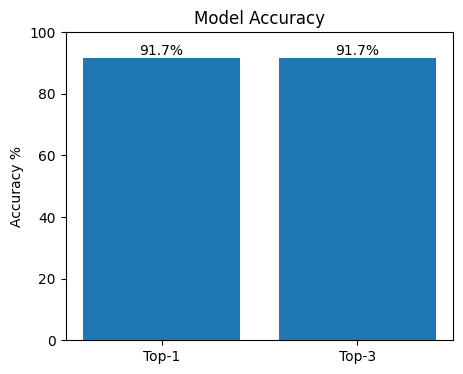

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Top-1", "Top-3"]
values = [top1_accuracy * 100, top3_accuracy * 100]

plt.figure(figsize=(5,4))
plt.bar(metrics, values)

plt.ylabel("Accuracy %")
plt.title("Model Accuracy")

plt.ylim(0,100)

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()